# Extensions: H3, dynamics 2013–2025, education, Zensus 2011, map

This notebook extends `refugee_centres_afd_analysis.ipynb`. It rebuilds **exactly the same estimation
sample** (10,070 non-host municipalities, the same 15 controls) and adds:

| Section | Question | Outputs |
|---|---|---|
| 1 | H3: is the distance association weaker where ethnic diversity is higher? | tables 08–08e, figure 4 |
| 2 | Alternative exposure: centres and capacity within 25/50 km | table 09 |
| 3 | Dynamics 2013–2025: does the association exist before the 2015–16 arrivals? | tables 10–12, figure 5 |
| 4 | Do Zensus 2022 education and unemployment change the results? | tables 13, 13b |
| 5 | H3 with pre-crisis diversity (Zensus 2011) and sensitivity to cells published as “–” | tables 14, 14b |
| 6 | Map of AfD 2025 by district and the 157 centres | figure 0 |

Inputs: `data/shelters_non-host.xlsx` and `data/derived/` (built in `build_derived_data.ipynb`).
Results are written to `outputs_extensions/`, which the main notebook never touches.
Run from the `analysis/` folder: *Kernel → Restart & Run All* (about 7 minutes).

**Inference.** Every coefficient is reported with Kreis-clustered and nearest-centre-clustered
standard errors and with restricted wild cluster bootstrap p-values (Rademacher, 9,999 replications,
the main notebook's seed). `wcb_fast()` is the same algorithm as the main notebook's
`wild_cluster_bootstrap_t`, computed in closed form; it reproduces all six p-values of
`outputs/07_wild_cluster_bootstrap.csv` exactly (checked in the setup section). Every model is
checked for a full-rank design matrix.

## 0. Setup
Sample construction identical to the main notebook, clustered SEs, bootstrap and helpers.

In [1]:
from IPython.display import display
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="invalid value encountered in sqrt")

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA = ROOT / "data" / "shelters_non-host.xlsx"
DERIVED = ROOT / "data" / "derived"
RAW = ROOT / "data" / "raw"            # optional, only needed to rebuild data/derived
OUT = ROOT / "outputs_extensions"
FIG = OUT / "figures"
OUT.mkdir(exist_ok=True)
FIG.mkdir(exist_ok=True)

SEED = 20261002
B_BOOT = 9999

CONTROLS = [
    "ln_population_2021", "population_density_2021", "purchasing_power_pc_2021",
    "share_65plus_2021", "female_share_2021", "net_migration_rate_2021",
    "urban_dummy", "suburban_dummy", "foreign_share_zensus2022",
    "immig_history_share_zensus2022", "immigrated_share_zensus2022",
    "share_60plus_zensus2022", "female_share_zensus2022", "zensus_population_2022",
    "turnout_2021_pct",
]
CTRL = " + ".join(CONTROLS)
# Zensus 2022 education/employment (municipality -> Gemeindeverband -> Kreis fill) + fill-level dummies
EDU = "abitur_share_z22 + novoc_share_z22 + unemp_rate_z22 + edu_lvl_gv + edu_lvl_kr"
LAND_FE, KREIS_FE = "C(State_code)", "C(Kreis_code)"
KREIS_CONSTANT = {"foreign_share_2021", "unemployment_rate_2021", "tertiary_education_share_2022"}


def load_baseline():
    df = pd.read_excel(DATA, sheet_name=0, dtype={"AGS8": str})
    for c in ["State_code", "Kreis_code", "nearest_shelter_id"]:
        df[c] = df[c].astype("string")
    if (df["n_shelters_in_municipality"].fillna(0) > 0).any():
        raise ValueError("expected a non-host sample")
    df["ln_distance"] = np.log(df["distance_nearest_shelter_km"])
    df["ln_population_2021"] = np.log(df["population_2021"])
    need = ["afd_share_2025_pct", "ln_distance", "State_code", "Kreis_code", "nearest_shelter_id"] + CONTROLS
    base = df.dropna(subset=need).copy()
    assert len(base) == 10_070, len(base)
    return base


def load_panel(require_years=True, require_edu=False):
    """Baseline + AfD 2013-2025 (GERDA) + exposure measures + Zensus 2022 education."""
    base = load_baseline()
    idx = base.index
    g = pd.read_csv(DERIVED / "gerda_afd_2013_2025.csv", dtype={"AGS8": str})
    ex = pd.read_csv(DERIVED / "exposure_measures.csv", dtype={"AGS8": str})
    ed = pd.read_csv(DERIVED / "education_zensus2022.csv", dtype={"AGS8": str})
    p = (base.reset_index().merge(g, on="AGS8", how="left").merge(ex, on="AGS8", how="left")
             .merge(ed, on="AGS8", how="left").set_index("index"))
    assert p.index.equals(idx)
    p["edu_lvl_gv"] = (p["abitur_share_lvl"] == "Gemeindeverband").astype(int)
    p["edu_lvl_kr"] = (p["abitur_share_lvl"] == "Kreis").astype(int)
    if require_years:
        p = p.dropna(subset=[f"afd{y}" for y in (2013, 2017, 2021, 2025)])
    if require_edu:
        p = p.dropna(subset=["abitur_share_z22", "novoc_share_z22", "unemp_rate_z22"])
    return p


def split(d):
    west = d[d["east_dummy"] == 0].copy()
    east = d[d["east_dummy"] == 1].copy()
    east_no_mv = east[east["State_code"].str.zfill(2) != "13"].copy()
    return west, east, east_no_mv


def with_z(d, var, name="Z"):
    d = d.copy()
    d[name] = (d[var] - d[var].mean()) / d[var].std()
    return d


def fit(formula, data, weights=None):
    if weights is None:
        return smf.ols(formula, data=data).fit()
    return smf.wls(formula, data=data, weights=data[weights]).fit()


def cluster_result(model, data, cluster):
    groups = data.loc[model.model.data.row_labels, cluster]
    return model.get_robustcov_results(cov_type="cluster", groups=groups), groups


def cluster_stats(model, data, cluster, term):
    r, groups = cluster_result(model, data, cluster)
    j = list(model.params.index).index(term)
    return float(r.bse[j]), float(r.pvalues[j]), int(groups.nunique())


def check_rank(model):
    X = model.model.exog
    assert np.linalg.matrix_rank(X) == X.shape[1], "rank-deficient design matrix"


def _resid_on(X0, V):
    coef, *_ = np.linalg.lstsq(X0, V, rcond=None)
    return V - X0 @ coef


def wcb_fast(model, data, term, cluster, B=B_BOOT, seed=SEED, chunk=2000):
    used = model.model.data.row_labels
    groups = data.loc[used, cluster].astype(str).to_numpy()
    _, g = np.unique(groups, return_inverse=True)
    G = g.max() + 1
    X = np.asarray(model.model.exog, float)
    y = np.asarray(model.model.endog, float)
    j = list(model.model.exog_names).index(term)
    X0 = np.delete(X, j, axis=1)
    xt = _resid_on(X0, X[:, j])
    D = xt @ xt
    r = _resid_on(X0, y)                                  # restricted residuals (H0 imposed)
    b_obs = (xt @ r) / D
    S_obs = np.bincount(g, weights=xt * (r - xt * b_obs), minlength=G)
    t_obs = b_obs / np.sqrt((S_obs ** 2).sum()) * D
    a = np.bincount(g, weights=xt * r, minlength=G)
    w = np.bincount(g, weights=xt * xt, minlength=G)
    R = np.zeros((len(y), G))
    R[np.arange(len(y)), g] = r
    PR = R - _resid_on(X0, R)
    Q = np.zeros((G, G))
    np.add.at(Q, g, xt[:, None] * PR)
    rng = np.random.default_rng(seed)
    signs = np.stack([rng.choice([-1.0, 1.0], size=G) for _ in range(B)])
    exceed = 0
    for k in range(0, B, chunk):
        s = signs[k:k + chunk]
        bs = (s @ a) / D
        S = s * a - s @ Q.T - bs[:, None] * w
        exceed += int((np.abs(bs / np.sqrt((S ** 2).sum(1)) * D) >= abs(t_obs)).sum())
    return (exceed + 1) / (B + 1)


def result_row(model, data, term, /, bootstrap=True, **meta):
    """Coefficient with Kreis- and centre-clustered SE/p and (optionally) WCB p-values."""
    check_rank(model)
    out = dict(meta, N=int(model.nobs), beta=float(model.params[term]))
    for cl, tag in [("Kreis_code", "Kreis"), ("nearest_shelter_id", "shelter")]:
        se, p, G = cluster_stats(model, data, cl, term)
        out.update({f"SE_{tag}": se, f"p_{tag}": p, f"G_{tag}": G})
        if bootstrap:
            out[f"WCB_p_{tag}"] = wcb_fast(model, data, term, cl)
    return out


def save(rows, name):
    t = pd.DataFrame(rows)
    t.to_csv(OUT / name, index=False)
    print(f"wrote outputs_extensions/{name} ({len(t)} rows)")
    return t

**Check:** `wcb_fast()` reproduces the six bootstrap p-values of the main notebook (`outputs/07_wild_cluster_bootstrap.csv`).

In [2]:
base = load_baseline()
west, east, east_no_mv = split(base)
F_STATE = f"afd_share_2025_pct ~ ln_distance + {LAND_FE} + {CTRL}"
F_BINS = f"afd_share_2025_pct ~ C(distance_bin, Treatment(reference='0-5')) + {LAND_FE} + {CTRL}"
east_no_mv["distance_bin"] = pd.cut(east_no_mv.distance_nearest_shelter_km, [0, 5, 10, 20, 40, np.inf],
                                    right=False, labels=["0-5", "5-10", "10-20", "20-40", "40+"])
t40 = "C(distance_bin, Treatment(reference='0-5'))[T.40+]"
mine = [wcb_fast(fit(F_STATE, d), d, "ln_distance", c) for d in (east, east_no_mv)
        for c in ("nearest_shelter_id", "Kreis_code")]
mine += [wcb_fast(fit(F_BINS, east_no_mv), east_no_mv, t40, c) for c in ("nearest_shelter_id", "Kreis_code")]
ref = pd.read_csv(ROOT / "outputs" / "07_wild_cluster_bootstrap.csv")
check = ref[["model", "cluster_var", "WCB_p"]].assign(wcb_fast=mine)
assert np.allclose(check.WCB_p, check.wcb_fast), check
display(check)

,model,cluster_var,WCB_p,wcb_fast
0,East Land FE,nearest_shelter_id,0.0171,0.0171
1,East Land FE,Kreis_code,0.0256,0.0256
2,East Land FE excluding MV municipalities,nearest_shelter_id,0.1140,0.1140
3,East Land FE excluding MV municipalities,Kreis_code,0.2751,0.2751
4,East bins Land FE excluding MV municipalities,nearest_shelter_id,0.0473,0.0473
5,East bins Land FE excluding MV municipalities,Kreis_code,0.0324,0.0324


## 1. H3: distance × ethnic diversity (2025)

```text
H3: is the distance association weaker where pre-existing ethnic diversity is higher?

Moderators (z-scored within each estimation sample, so the ln_distance main effect is the
slope at mean diversity and the interaction is the change in that slope per 1 SD):
  foreign_share_zensus2022  municipal (varies within Kreis)
  foreign_share_2021        district, INKAR (constant within Kreis)
Same 15 controls, Land FE and Kreis FE, Germany / West / East, 2025 AfD share.
Design rule: the moderator's main effect is omitted when it is already in the model (it is one
of the controls, or it is absorbed by Kreis FE); keeping it makes the design rank-deficient and
the pinv-based cluster SE unstable. Every model is rank-checked.
Outputs: 08_h3_interactions.csv, 08b_h3_pooled_composition.csv,
         08c_h3_west_district_robustness.csv, 08d_h3_west_marginal_slopes.csv,
         08e_h3_west_terciles.csv, figures/figure4_h3_west_marginal_slope.{png,pdf}
```

In [3]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

MODS = {"foreign_share_zensus2022": "Municipal foreign share (Zensus 2022)",
        "foreign_share_2021": "District foreign share (INKAR 2021)"}
FES = {"Land FE": LAND_FE, "Kreis FE": KREIS_FE}


def formula(mod, fe, ctrl=CTRL, x="ln_distance", extra=""):
    absorbed = (fe == KREIS_FE and mod in KREIS_CONSTANT) or mod in ctrl.split(" + ")
    core = f"{x} + {x}:Z" if absorbed else f"{x} * Z"
    return f"afd_share_2025_pct ~ {core}{extra} + {fe} + {ctrl}"


base = load_baseline()
west, east, _ = split(base)

### 1. main grid

In [4]:
rows = []
for mod, mlab in MODS.items():
    for sname, s in {"Germany": base, "West": west, "East": east}.items():
        d = with_z(s, mod)
        for fname, fe in FES.items():
            m = fit(formula(mod, fe), d)
            for term in ["ln_distance", "ln_distance:Z"]:
                rows.append(result_row(m, d, term, moderator=mlab, sample=sname, model=fname, coef=term,
                                       moderator_mean=s[mod].mean(), moderator_sd=s[mod].std()))
save(rows, "08_h3_interactions.csv")

wrote outputs_extensions/08_h3_interactions.csv (24 rows)


,moderator,sample,model,coef,moderator_mean,moderator_sd,N,beta,SE_Kreis,p_Kreis,G_Kreis,WCB_p_Kreis,SE_shelter,p_shelter,G_shelter,WCB_p_shelter
0,Municipal foreign share (Zensus 2022),Germany,Land FE,ln_distance,6.992799,5.206577,10070,0.168795,0.277700,0.543683,361,0.5654,0.261743,0.520034,144,0.5747
1,Municipal foreign share (Zensus 2022),Germany,Land FE,ln_distance:Z,6.992799,5.206577,10070,-0.304548,0.145554,0.037108,361,0.0492,0.148750,0.042451,144,0.0771
2,Municipal foreign share (Zensus 2022),Germany,Kreis FE,ln_distance,6.992799,5.206577,10070,0.033050,0.186403,0.859368,361,0.8516,0.194215,0.865114,144,0.8694
3,Municipal foreign share (Zensus 2022),Germany,Kreis FE,ln_distance:Z,6.992799,5.206577,10070,-0.041569,0.112234,0.711322,361,0.7245,0.124554,0.739065,144,0.7471
4,Municipal foreign share (Zensus 2022),West,Land FE,ln_distance,8.089753,5.124266,7920,-0.325914,0.282163,0.249011,293,0.2893,0.252882,0.200032,117,0.2673
5,Municipal foreign share (Zensus 2022),West,Land FE,ln_distance:Z,8.089753,5.124266,7920,0.069338,0.169715,0.683167,293,0.7013,0.147887,0.640053,117,0.6587
6,Municipal foreign share (Zensus 2022),West,Kreis FE,ln_distance,8.089753,5.124266,7920,-0.111173,0.199488,0.577754,293,0.5784,0.216100,0.607913,117,0.6386
7,Municipal foreign share (Zensus 2022),West,Kreis FE,ln_distance:Z,8.089753,5.124266,7920,0.054556,0.141850,0.700810,293,0.7127,0.169489,0.748117,117,0.7674
8,Municipal foreign share (Zensus 2022),East,Land FE,ln_distance,2.951929,3.079548,2150,1.377179,0.474683,0.005024,68,0.0248,0.361883,0.000500,39,0.0166
9,Municipal foreign share (Zensus 2022),East,Land FE,ln_distance:Z,2.951929,3.079548,2150,0.268072,0.179189,0.139342,68,0.2367,0.231491,0.254082,39,0.4383


### 2. pooled interaction = East/West composition?

In [5]:
rows = []
for mod, mlab in MODS.items():
    d = with_z(base, mod)
    for fname, fe in FES.items():
        absorbed = fe == KREIS_FE and mod in KREIS_CONSTANT
        for spec, extra in [("Pooled", ""),
                            ("Pooled + region-specific slope",
                             " + ln_distance:east_dummy" + ("" if absorbed else " + Z:east_dummy"))]:
            m = fit(formula(mod, fe, extra=extra), d)
            rows.append(result_row(m, d, "ln_distance:Z", moderator=mlab, model=fname, spec=spec))
save(rows, "08b_h3_pooled_composition.csv")

wrote outputs_extensions/08b_h3_pooled_composition.csv (8 rows)


,moderator,model,spec,N,beta,SE_Kreis,p_Kreis,G_Kreis,WCB_p_Kreis,SE_shelter,p_shelter,G_shelter,WCB_p_shelter
0,Municipal foreign share (Zensus 2022),Land FE,Pooled,10070,-0.304548,0.145554,0.037108,361,0.0492,0.148750,0.042451,144,0.0771
1,Municipal foreign share (Zensus 2022),Land FE,Pooled + region-specific slope,10070,0.203257,0.164271,0.216771,361,0.2632,0.158386,0.201462,144,0.2576
2,Municipal foreign share (Zensus 2022),Kreis FE,Pooled,10070,-0.041569,0.112234,0.711322,361,0.7245,0.124554,0.739065,144,0.7471
3,Municipal foreign share (Zensus 2022),Kreis FE,Pooled + region-specific slope,10070,0.187789,0.134717,0.164191,361,0.1857,0.161175,0.245908,144,0.2937
4,District foreign share (INKAR 2021),Land FE,Pooled,10070,-0.606266,0.225948,0.007628,361,0.0149,0.182890,0.001162,144,0.0038
5,District foreign share (INKAR 2021),Land FE,Pooled + region-specific slope,10070,0.129597,0.269656,0.631091,361,0.6621,0.183276,0.480645,144,0.5087
6,District foreign share (INKAR 2021),Kreis FE,Pooled,10070,0.039088,0.175435,0.823812,361,0.8285,0.170536,0.819035,144,0.8201
7,District foreign share (INKAR 2021),Kreis FE,Pooled + region-specific slope,10070,0.574693,0.194292,0.003302,361,0.0059,0.190451,0.003018,144,0.0048


### 3. robustness of the West district-level interaction

In [6]:
MOD = "foreign_share_2021"
wz = with_z(west, MOD)
COMPETING = ["unemployment_rate_2021", "tertiary_education_share_2022", "purchasing_power_pc_2021",
             "urban_dummy", "ln_population_2021", "population_density_2021", "foreign_share_zensus2022",
             "share_65plus_2021", "turnout_2021_pct", "net_migration_rate_2021"]
for v in COMPETING:
    wz["O_" + v] = (wz[v] - wz[v].mean()) / wz[v].std()
NOPT = " + ".join(c for c in CONTROLS if c not in [
    "foreign_share_zensus2022", "immig_history_share_zensus2022", "immigrated_share_zensus2022",
    "turnout_2021_pct"])
rob = []


def add(label, d, f, weights=None, term="ln_distance:Z"):
    m = fit(f, d, weights)
    rob.append(result_row(m, d, term, bootstrap=weights is None, check=label))


add("Baseline: West, Kreis FE", wz, formula(MOD, KREIS_FE))
add("Land FE instead of Kreis FE", wz, formula(MOD, LAND_FE))
for v in COMPETING:
    add(f"+ ln_distance x {v}", wz, formula(MOD, KREIS_FE, extra=f" + ln_distance:O_{v}"))
add("+ all 10 competing interactions", wz,
    formula(MOD, KREIS_FE, extra="".join(f" + ln_distance:O_{v}" for v in COMPETING)))
add("Without post-treatment controls (Zensus migration shares, turnout)", wz, formula(MOD, KREIS_FE, ctrl=NOPT))
add("Population-weighted (WLS)", wz, formula(MOD, KREIS_FE), weights="population_2021")
add("Distance in km instead of log", wz, formula(MOD, KREIS_FE, x="distance_nearest_shelter_km"),
    term="distance_nearest_shelter_km:Z")
for lab, flag in [("Exclude coarse coordinates", "nearest_shelter_coord_coarse"),
                  ("Exclude sensitivity cases", "nearest_shelter_sensitivity_case")]:
    add(lab, with_z(west[west[flag].str.lower() != "yes"], MOD), formula(MOD, KREIS_FE))
for L in sorted(west["State_code"].str.zfill(2).unique()):
    d = west[west["State_code"].str.zfill(2) != L]
    if len(west) - len(d) >= 10:                     # skips Bremen (1 municipality)
        add(f"Drop Land {L} (n={len(west) - len(d)})", with_z(d, MOD), formula(MOD, KREIS_FE))
save(rob, "08c_h3_west_district_robustness.csv")

wrote outputs_extensions/08c_h3_west_district_robustness.csv (26 rows)


,check,N,beta,SE_Kreis,p_Kreis,G_Kreis,WCB_p_Kreis,SE_shelter,p_shelter,G_shelter,WCB_p_shelter
0,"Baseline: West, Kreis FE",7920,0.544053,0.173452,0.001883,293,0.0020,0.169595,0.001728,117,0.0029
1,Land FE instead of Kreis FE,7920,0.107954,0.232067,0.642145,293,0.6775,0.156883,0.492752,117,0.5337
2,+ ln_distance x unemployment_rate_2021,7920,0.492124,0.163412,0.002826,293,0.0034,0.151875,0.001558,117,0.0024
3,+ ln_distance x tertiary_education_share_2022,7920,0.493776,0.187966,0.009070,293,0.0134,0.186360,0.009183,117,0.0135
4,+ ln_distance x purchasing_power_pc_2021,7920,0.535467,0.171053,0.001922,293,0.0023,0.166031,0.001636,117,0.0030
5,+ ln_distance x urban_dummy,7920,0.560359,0.173798,0.001407,293,0.0015,0.169961,0.001297,117,0.0025
6,+ ln_distance x ln_population_2021,7920,0.476715,0.166787,0.004567,293,0.0049,0.158047,0.003145,117,0.0052
7,+ ln_distance x population_density_2021,7920,0.554324,0.176987,0.001912,293,0.0020,0.168946,0.001366,117,0.0027
8,+ ln_distance x foreign_share_zensus2022,7920,0.622093,0.190139,0.001197,293,0.0012,0.204477,0.002903,117,0.0052
9,+ ln_distance x share_65plus_2021,7920,0.521287,0.175572,0.003235,293,0.0032,0.177184,0.003938,117,0.0050


### 4. marginal slopes, terciles, figure

wrote outputs_extensions/08d_h3_west_marginal_slopes.csv (5 rows)


wrote outputs_extensions/08e_h3_west_terciles.csv (4 rows)


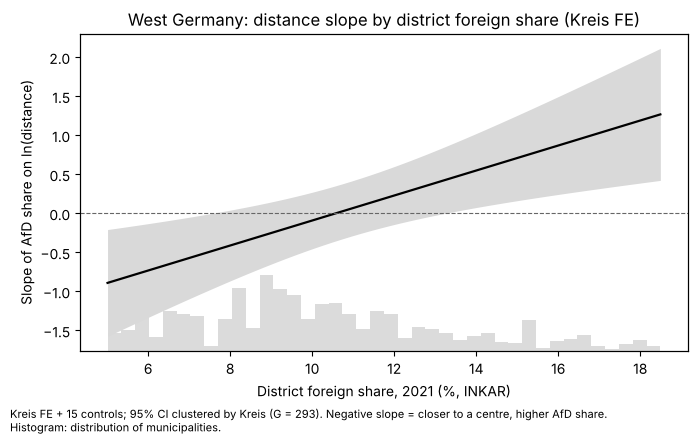

In [7]:
m = fit(formula(MOD, KREIS_FE), wz)
rc, grp = cluster_result(m, wz, "Kreis_code")
names = list(m.params.index)
i, j = names.index("ln_distance"), names.index("ln_distance:Z")
V, G = rc.cov_params(), grp.nunique()
tc = stats.t.ppf(0.975, G - 1)
mu, sd = west[MOD].mean(), west[MOD].std()
grid = np.linspace(west[MOD].quantile(0.02), west[MOD].quantile(0.98), 60)
ms = []
for q, v in [(None, x) for x in grid] + [(q, west[MOD].quantile(q)) for q in [.1, .25, .5, .75, .9]]:
    zz = (v - mu) / sd
    b = m.params.iloc[i] + zz * m.params.iloc[j]
    se = np.sqrt(V[i, i] + zz ** 2 * V[j, j] + 2 * zz * V[i, j])
    ms.append(dict(percentile=q, foreign_share_2021=v, slope=b, SE=se, lo=b - tc * se, hi=b + tc * se,
                   p=2 * stats.t.sf(abs(b / se), G - 1)))
ms = pd.DataFrame(ms)
save(ms[ms.percentile.notna()], "08d_h3_west_marginal_slopes.csv")

wt = west.copy()
wt["tercile"] = pd.qcut(wt[MOD].rank(method="first"), 3, labels=["low", "mid", "high"])
mt = fit(f"afd_share_2025_pct ~ ln_distance:C(tercile) + {KREIS_FE} + {CTRL}", wt)
rt, _ = cluster_result(mt, wt, "Kreis_code")
rows = []
for t in ["low", "mid", "high"]:
    k = list(mt.params.index).index(f"ln_distance:C(tercile)[{t}]")
    sub = wt[wt.tercile == t]
    rows.append(dict(tercile=t, share_min=sub[MOD].min(), share_max=sub[MOD].max(), N=len(sub),
                     Kreise=sub.Kreis_code.nunique(), slope=mt.params.iloc[k], SE_Kreis=rt.bse[k],
                     p_Kreis=rt.pvalues[k]))
wt["hi"], wt["mid"] = (wt.tercile == "high").astype(float), (wt.tercile == "mid").astype(float)
md = fit(f"afd_share_2025_pct ~ ln_distance + ln_distance:hi + ln_distance:mid + {KREIS_FE} + {CTRL}", wt)
r = result_row(md, wt, "ln_distance:hi")
rows.append(dict(tercile="high - low", slope=r["beta"], SE_Kreis=r["SE_Kreis"], p_Kreis=r["p_Kreis"],
                 WCB_p_Kreis=r["WCB_p_Kreis"], WCB_p_shelter=r["WCB_p_shelter"]))
save(rows, "08e_h3_west_terciles.csv")

g = ms[ms.percentile.isna()]
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.fill_between(g.foreign_share_2021, g.lo, g.hi, color="0.85", lw=0)
ax.plot(g.foreign_share_2021, g.slope, color="black", lw=1.6)
ax.axhline(0, color="0.4", lw=0.8, ls="--")
ax.set_xlabel("District foreign share, 2021 (%, INKAR)")
ax.set_ylabel("Slope of AfD share on ln(distance)")
ax2 = ax.twinx()
ax2.hist(west[MOD], bins=40, range=(grid.min(), grid.max()), color="0.6", alpha=0.35)
ax2.set_ylim(0, ax2.get_ylim()[1] * 4)
ax2.set_yticks([])
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)
ax.set_title("West Germany: distance slope by district foreign share (Kreis FE)")
fig.text(0.01, -0.04, f"Kreis FE + 15 controls; 95% CI clustered by Kreis (G = {G}). Negative slope = closer "
         "to a centre, higher AfD share.\nHistogram: distribution of municipalities.", fontsize=8, ha="left")
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG / f"figure4_h3_west_marginal_slope.{ext}", dpi=300, bbox_inches="tight")

**Results**

In [8]:
# Main grid (the H3 test is the ln_distance:Z row)
t = pd.read_csv(OUT / '08_h3_interactions.csv')
display(t[['moderator', 'sample', 'model', 'coef', 'N', 'beta', 'SE_Kreis', 'p_Kreis', 'WCB_p_Kreis', 'WCB_p_shelter']].round(4).reset_index(drop=True))

,moderator,sample,model,coef,N,beta,SE_Kreis,p_Kreis,WCB_p_Kreis,WCB_p_shelter
0,Municipal foreign share (Zensus 2022),Germany,Land FE,ln_distance,10070,0.1688,0.2777,0.5437,0.5654,0.5747
1,Municipal foreign share (Zensus 2022),Germany,Land FE,ln_distance:Z,10070,-0.3045,0.1456,0.0371,0.0492,0.0771
2,Municipal foreign share (Zensus 2022),Germany,Kreis FE,ln_distance,10070,0.0331,0.1864,0.8594,0.8516,0.8694
3,Municipal foreign share (Zensus 2022),Germany,Kreis FE,ln_distance:Z,10070,-0.0416,0.1122,0.7113,0.7245,0.7471
4,Municipal foreign share (Zensus 2022),West,Land FE,ln_distance,7920,-0.3259,0.2822,0.2490,0.2893,0.2673
5,Municipal foreign share (Zensus 2022),West,Land FE,ln_distance:Z,7920,0.0693,0.1697,0.6832,0.7013,0.6587
6,Municipal foreign share (Zensus 2022),West,Kreis FE,ln_distance,7920,-0.1112,0.1995,0.5778,0.5784,0.6386
7,Municipal foreign share (Zensus 2022),West,Kreis FE,ln_distance:Z,7920,0.0546,0.1419,0.7008,0.7127,0.7674
8,Municipal foreign share (Zensus 2022),East,Land FE,ln_distance,2150,1.3772,0.4747,0.0050,0.0248,0.0166
9,Municipal foreign share (Zensus 2022),East,Land FE,ln_distance:Z,2150,0.2681,0.1792,0.1393,0.2367,0.4383


In [9]:
# Pooled Germany interaction vs. region-specific slope
t = pd.read_csv(OUT / '08b_h3_pooled_composition.csv')
display(t[['moderator', 'model', 'spec', 'N', 'beta', 'SE_Kreis', 'p_Kreis', 'WCB_p_Kreis', 'WCB_p_shelter']].round(4).reset_index(drop=True))

,moderator,model,spec,N,beta,SE_Kreis,p_Kreis,WCB_p_Kreis,WCB_p_shelter
0,Municipal foreign share (Zensus 2022),Land FE,Pooled,10070,-0.3045,0.1456,0.0371,0.0492,0.0771
1,Municipal foreign share (Zensus 2022),Land FE,Pooled + region-specific slope,10070,0.2033,0.1643,0.2168,0.2632,0.2576
2,Municipal foreign share (Zensus 2022),Kreis FE,Pooled,10070,-0.0416,0.1122,0.7113,0.7245,0.7471
3,Municipal foreign share (Zensus 2022),Kreis FE,Pooled + region-specific slope,10070,0.1878,0.1347,0.1642,0.1857,0.2937
4,District foreign share (INKAR 2021),Land FE,Pooled,10070,-0.6063,0.2259,0.0076,0.0149,0.0038
5,District foreign share (INKAR 2021),Land FE,Pooled + region-specific slope,10070,0.1296,0.2697,0.6311,0.6621,0.5087
6,District foreign share (INKAR 2021),Kreis FE,Pooled,10070,0.0391,0.1754,0.8238,0.8285,0.8201
7,District foreign share (INKAR 2021),Kreis FE,Pooled + region-specific slope,10070,0.5747,0.1943,0.0033,0.0059,0.0048


In [10]:
# Robustness of the West, Kreis-FE district interaction
t = pd.read_csv(OUT / '08c_h3_west_district_robustness.csv')
display(t[['check', 'N', 'beta', 'SE_Kreis', 'p_Kreis', 'WCB_p_Kreis', 'WCB_p_shelter']].round(4).reset_index(drop=True))

,check,N,beta,SE_Kreis,p_Kreis,WCB_p_Kreis,WCB_p_shelter
0,"Baseline: West, Kreis FE",7920,0.5441,0.1735,0.0019,0.0020,0.0029
1,Land FE instead of Kreis FE,7920,0.1080,0.2321,0.6421,0.6775,0.5337
2,+ ln_distance x unemployment_rate_2021,7920,0.4921,0.1634,0.0028,0.0034,0.0024
3,+ ln_distance x tertiary_education_share_2022,7920,0.4938,0.1880,0.0091,0.0134,0.0135
4,+ ln_distance x purchasing_power_pc_2021,7920,0.5355,0.1711,0.0019,0.0023,0.0030
5,+ ln_distance x urban_dummy,7920,0.5604,0.1738,0.0014,0.0015,0.0025
6,+ ln_distance x ln_population_2021,7920,0.4767,0.1668,0.0046,0.0049,0.0052
7,+ ln_distance x population_density_2021,7920,0.5543,0.1770,0.0019,0.0020,0.0027
8,+ ln_distance x foreign_share_zensus2022,7920,0.6221,0.1901,0.0012,0.0012,0.0052
9,+ ln_distance x share_65plus_2021,7920,0.5213,0.1756,0.0032,0.0032,0.0050


In [11]:
# Distance slope at percentiles of the district foreign share
t = pd.read_csv(OUT / '08d_h3_west_marginal_slopes.csv')
display(t.round(4).reset_index(drop=True))

,percentile,foreign_share_2021,slope,SE,lo,hi,p
0,0.10,6.10,-0.7161,0.3008,-1.3080,-0.1241,0.0179
1,0.25,8.15,-0.3879,0.2254,-0.8316,0.0557,0.0863
2,0.50,9.49,-0.1734,0.1916,-0.5506,0.2037,0.3661
3,0.75,11.89,0.2107,0.1867,-0.1567,0.5781,0.2599
4,0.90,15.35,0.7645,0.2915,0.1909,1.3382,0.0092


In [12]:
# Slopes by tercile and the high - low difference
t = pd.read_csv(OUT / '08e_h3_west_terciles.csv')
display(t.round(4).reset_index(drop=True))

,tercile,share_min,share_max,N,Kreise,slope,SE_Kreis,p_Kreis,WCB_p_Kreis,WCB_p_shelter
0,low,4.24,8.78,2640.0,68.0,-0.4895,0.3147,0.1210,NaN,NaN
1,mid,8.78,11.09,2640.0,76.0,-0.1414,0.3100,0.6487,NaN,NaN
2,high,11.09,37.54,2640.0,151.0,0.3830,0.2786,0.1703,NaN,NaN
3,high - low,NaN,NaN,NaN,NaN,0.8725,0.4110,0.0346,0.0492,0.0657


## 2. Alternative exposure measures and capacity

```text
Alternative exposure measures from the full registry (2025 levels).

  n_centres_25km / n_centres_50km   number of centres within the radius
  ln_cap25 / ln_cap50               log(1 + total capacity within the radius)
  inv_dist_sum                      sum over all 157 centres of 1/distance
  ln_distance x capacity            moderation by (z-scored log) capacity of the nearest centre
Germany / West / East x Land FE / Kreis FE, 15 controls. 36 tests in total; read together with
the 2013 placebo in 03_dynamics (the West density association is already present in 2013).
Output: 09_extra_exposure_all_tests.csv
```

In [13]:
import numpy as np

B = load_panel(require_years=False)
B["ln_capacity_nearest"] = np.log(B.nearest_shelter_capacity)
W, E, _ = split(B)
EXPO = ["n_centres_25km", "n_centres_50km", "ln_cap25", "ln_cap50", "inv_dist_sum"]
rows = []
for sn, s in {"Germany": B, "West": W, "East": E}.items():
    for fn, fe in {"Land FE": LAND_FE, "Kreis FE": KREIS_FE}.items():
        for v in EXPO:
            m = fit(f"afd_share_2025_pct ~ {v} + {fe} + {CTRL}", s)
            rows.append(result_row(m, s, v, analysis="exposure", variable=v, sample=sn, model=fn))
        d = s.dropna(subset=["ln_capacity_nearest"]).copy()
        d["Zc"] = (d.ln_capacity_nearest - d.ln_capacity_nearest.mean()) / d.ln_capacity_nearest.std()
        m = fit(f"afd_share_2025_pct ~ ln_distance * Zc + {fe} + {CTRL}", d)
        rows.append(result_row(m, d, "ln_distance", analysis="capacity moderation",
                               variable="ln_distance (at mean capacity)", sample=sn, model=fn))
        rows.append(result_row(m, d, "ln_distance:Zc", analysis="capacity moderation",
                               variable="ln_distance x capacity", sample=sn, model=fn))
save(rows, "09_extra_exposure_all_tests.csv")

wrote outputs_extensions/09_extra_exposure_all_tests.csv (42 rows)


,analysis,variable,sample,model,N,beta,SE_Kreis,p_Kreis,G_Kreis,WCB_p_Kreis,SE_shelter,p_shelter,G_shelter,WCB_p_shelter
0,exposure,n_centres_25km,Germany,Land FE,10070,-0.035344,0.097794,0.718000,361,0.7304,0.089714,0.694193,144,0.7065
1,exposure,n_centres_50km,Germany,Land FE,10070,0.101193,0.059197,0.088235,361,0.1129,0.061227,0.100575,144,0.1431
2,exposure,ln_cap25,Germany,Land FE,10070,0.006791,0.048944,0.889718,361,0.8961,0.042370,0.872880,144,0.8847
3,exposure,ln_cap50,Germany,Land FE,10070,-0.057488,0.061007,0.346666,361,0.3948,0.058337,0.326073,144,0.3888
4,exposure,inv_dist_sum,Germany,Land FE,10070,0.328291,1.503553,0.827285,361,0.8358,1.688990,0.846161,144,0.8664
5,capacity moderation,ln_distance (at mean capacity),Germany,Land FE,8598,0.149245,0.304621,0.624499,337,0.6532,0.309443,0.630508,116,0.6792
6,capacity moderation,ln_distance x capacity,Germany,Land FE,8598,-0.488321,0.255182,0.056519,337,0.1070,0.279607,0.083403,116,0.1607
7,exposure,n_centres_25km,Germany,Kreis FE,10070,-0.197414,0.062220,0.001639,361,0.0042,0.058669,0.000983,144,0.0053
8,exposure,n_centres_50km,Germany,Kreis FE,10070,-0.074019,0.051226,0.149341,361,0.1837,0.046208,0.111392,144,0.1696
9,exposure,ln_cap25,Germany,Kreis FE,10070,-0.014342,0.028788,0.618654,361,0.6177,0.030317,0.636882,144,0.6372


**Results**

In [14]:
t = pd.read_csv(OUT / '09_extra_exposure_all_tests.csv')
display(t[['analysis', 'variable', 'sample', 'model', 'N', 'beta', 'SE_Kreis', 'p_Kreis', 'WCB_p_Kreis', 'WCB_p_shelter']].round(4).reset_index(drop=True))

,analysis,variable,sample,model,N,beta,SE_Kreis,p_Kreis,WCB_p_Kreis,WCB_p_shelter
0,exposure,n_centres_25km,Germany,Land FE,10070,-0.0353,0.0978,0.7180,0.7304,0.7065
1,exposure,n_centres_50km,Germany,Land FE,10070,0.1012,0.0592,0.0882,0.1129,0.1431
2,exposure,ln_cap25,Germany,Land FE,10070,0.0068,0.0489,0.8897,0.8961,0.8847
3,exposure,ln_cap50,Germany,Land FE,10070,-0.0575,0.0610,0.3467,0.3948,0.3888
4,exposure,inv_dist_sum,Germany,Land FE,10070,0.3283,1.5036,0.8273,0.8358,0.8664
5,capacity moderation,ln_distance (at mean capacity),Germany,Land FE,8598,0.1492,0.3046,0.6245,0.6532,0.6792
6,capacity moderation,ln_distance x capacity,Germany,Land FE,8598,-0.4883,0.2552,0.0565,0.1070,0.1607
7,exposure,n_centres_25km,Germany,Kreis FE,10070,-0.1974,0.0622,0.0016,0.0042,0.0053
8,exposure,n_centres_50km,Germany,Kreis FE,10070,-0.0740,0.0512,0.1493,0.1837,0.1696
9,exposure,ln_cap25,Germany,Kreis FE,10070,-0.0143,0.0288,0.6187,0.6177,0.6372


## 3. Dynamics 2013–2025 and the 2013 placebo

```text
Dynamics with GERDA 2013-2025 (constant sample: every municipality observed in all four
elections, N = 10,069; West 7,919, East 2,150). The 2013 election is the last one before the
2015-16 arrivals peak and serves as a placebo. The registry is a 2025 snapshot.

  10_gerda_change_and_placebo.csv     change 2021-25 / 2017-25 and 2013 placebo levels (AfD, NPD)
  11_coefficient_profile_by_election.csv  the same specification estimated on each election
  12_change_from_2013.csv             changes 2013->2017 / 2021 / 2025
  figures/figure5_coefficients_by_election.{png,pdf}
```

In [15]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

FE = {"Land FE": LAND_FE, "Kreis FE": KREIS_FE}

### 10: change outcomes and placebo levels (sample: non-missing outcome)

In [16]:
P = load_panel(require_years=False)
P["d_afd_21_25"] = P.afd2025 - P.afd2021
P["d_afd_17_25"] = P.afd2025 - P.afd2017
OUTC = {"d_afd_21_25": "Change AfD 2021-25", "d_afd_17_25": "Change AfD 2017-25",
        "afd2013": "Placebo: AfD 2013 level", "npd2013": "Placebo: NPD 2013 level"}
rows = []
for y, ylab in OUTC.items():
    D = P.dropna(subset=[y])
    W, E, EN = split(D)
    for sn, s in {"Germany": D, "West": W, "East": E, "East excl. MV": EN}.items():
        for fn, fe in FE.items():
            m = fit(f"{y} ~ ln_distance + {fe} + {CTRL}", s)
            rows.append(result_row(m, s, "ln_distance", outcome=ylab, spec="ln_distance", sample=sn, model=fn))
    w = with_z(W, "foreign_share_2021")
    m = fit(f"{y} ~ ln_distance + ln_distance:Z + {KREIS_FE} + {CTRL}", w)
    rows.append(result_row(m, w, "ln_distance:Z", outcome=ylab, spec="H3: ln_distance x district foreign share",
                           sample="West", model="Kreis FE"))
    for fn, fe in FE.items():
        m = fit(f"{y} ~ n_centres_50km + {fe} + {CTRL}", w)
        rows.append(result_row(m, w, "n_centres_50km", outcome=ylab, spec="n_centres_50km", sample="West", model=fn))
save(rows, "10_gerda_change_and_placebo.csv")

wrote outputs_extensions/10_gerda_change_and_placebo.csv (44 rows)


,outcome,spec,sample,model,N,beta,SE_Kreis,p_Kreis,G_Kreis,WCB_p_Kreis,SE_shelter,p_shelter,G_shelter,WCB_p_shelter
0,Change AfD 2021-25,ln_distance,Germany,Land FE,10069,-0.090887,0.095298,0.340867,361,0.3721,0.089265,3.103169e-01,144,0.3464
1,Change AfD 2021-25,ln_distance,Germany,Kreis FE,10069,0.021703,0.086960,0.803060,361,0.8098,0.091401,8.126501e-01,144,0.8332
2,Change AfD 2021-25,ln_distance,West,Land FE,7919,-0.100331,0.115719,0.386640,293,0.4078,0.109925,3.632813e-01,117,0.4050
3,Change AfD 2021-25,ln_distance,West,Kreis FE,7919,0.029076,0.104304,0.780626,293,0.7814,0.115197,8.011775e-01,117,0.8321
4,Change AfD 2021-25,ln_distance,East,Land FE,2150,-0.101467,0.140176,0.471675,68,0.5581,0.133488,4.518739e-01,39,0.5370
5,Change AfD 2021-25,ln_distance,East,Kreis FE,2150,-0.083107,0.151473,0.585063,68,0.5978,0.114610,4.728157e-01,39,0.5324
6,Change AfD 2021-25,ln_distance,East excl. MV,Land FE,1500,-0.059531,0.125526,0.637040,61,0.6544,0.135007,6.618878e-01,37,0.6874
7,Change AfD 2021-25,ln_distance,East excl. MV,Kreis FE,1500,-0.002959,0.180111,0.986946,61,0.9856,0.130921,9.820923e-01,37,0.9823
8,Change AfD 2021-25,H3: ln_distance x district foreign share,West,Kreis FE,7919,0.195248,0.102957,0.058893,293,0.0696,0.107225,7.119712e-02,117,0.0888
9,Change AfD 2021-25,n_centres_50km,West,Land FE,7919,0.089565,0.028551,0.001881,293,0.0047,0.031390,5.125571e-03,117,0.0166


### 11 / 12: constant four-election sample

In [17]:
B = load_panel(require_years=True)
W, E, EN = split(B)
W = with_z(W, "foreign_share_2021")
SPECS = [("Germany", "Land FE", B, "ln_distance", LAND_FE, ""), ("Germany", "Kreis FE", B, "ln_distance", KREIS_FE, ""),
         ("West", "Land FE", W, "ln_distance", LAND_FE, ""), ("West", "Kreis FE", W, "ln_distance", KREIS_FE, ""),
         ("East", "Land FE", E, "ln_distance", LAND_FE, ""), ("East", "Kreis FE", E, "ln_distance", KREIS_FE, ""),
         ("West", "Kreis FE (H3)", W, "ln_distance:Z", KREIS_FE, " + ln_distance:Z"),
         ("West", "Land FE (density)", W, "n_centres_50km", LAND_FE, "")]
rows = []
for sn, fn, d, term, fe, extra in SPECS:
    for y in (2013, 2017, 2021, 2025):
        rhs = "ln_distance" if term == "ln_distance:Z" else term
        m = fit(f"afd{y} ~ {rhs}{extra} + {fe} + {CTRL}", d)
        r = result_row(m, d, term, sample=sn, model=fn, term=term, year=y)
        r["mean_afd"] = d[f"afd{y}"].mean()
        rows.append(r)
prof = save(rows, "11_coefficient_profile_by_election.csv")

rows = []
for a, b in [(2013, 2017), (2013, 2021), (2013, 2025)]:
    for lab, d, term, fe, extra in [("West Kreis FE: H3 interaction", W, "ln_distance:Z", KREIS_FE, " + ln_distance:Z"),
                                    ("West Land FE: ln_distance", W, "ln_distance", LAND_FE, ""),
                                    ("West Kreis FE: ln_distance", W, "ln_distance", KREIS_FE, ""),
                                    ("East Land FE: ln_distance", E, "ln_distance", LAND_FE, ""),
                                    ("East excl. MV Land FE: ln_distance", EN, "ln_distance", LAND_FE, ""),
                                    ("East Kreis FE: ln_distance", E, "ln_distance", KREIS_FE, "")]:
        m = fit(f"I(afd{b} - afd{a}) ~ ln_distance{extra} + {fe} + {CTRL}", d)
        rows.append(result_row(m, d, term, change=f"{a}->{b}", spec=lab))
save(rows, "12_change_from_2013.csv")

wrote outputs_extensions/11_coefficient_profile_by_election.csv (32 rows)


wrote outputs_extensions/12_change_from_2013.csv (18 rows)


,change,spec,N,beta,SE_Kreis,p_Kreis,G_Kreis,WCB_p_Kreis,SE_shelter,p_shelter,G_shelter,WCB_p_shelter
0,2013->2017,West Kreis FE: H3 interaction,7919,0.363970,0.101672,0.000402,293,0.0002,0.099170,0.000368,117,0.0005
1,2013->2017,West Land FE: ln_distance,7919,-0.442042,0.186250,0.018273,293,0.0266,0.145685,0.002977,117,0.0120
2,2013->2017,West Kreis FE: ln_distance,7919,-0.211055,0.104327,0.043983,293,0.0460,0.098667,0.034528,117,0.0429
3,2013->2017,East Land FE: ln_distance,2150,1.378103,0.374837,0.000472,68,0.0029,0.239770,0.000001,39,0.0004
4,2013->2017,East excl. MV Land FE: ln_distance,1500,1.050565,0.418185,0.014705,61,0.0254,0.294310,0.001036,37,0.0015
5,2013->2017,East Kreis FE: ln_distance,2150,0.444801,0.345329,0.202159,68,0.1968,0.319910,0.172500,39,0.1633
6,2013->2021,West Kreis FE: H3 interaction,7919,0.435242,0.102250,0.000028,293,0.0001,0.110046,0.000132,117,0.0011
7,2013->2021,West Land FE: ln_distance,7919,-0.164318,0.180170,0.362513,293,0.4092,0.162798,0.314916,117,0.3877
8,2013->2021,West Kreis FE: ln_distance,7919,-0.084865,0.126980,0.504450,293,0.5056,0.154791,0.584572,117,0.6143
9,2013->2021,East Land FE: ln_distance,2150,1.402885,0.358445,0.000215,68,0.0053,0.291596,0.000024,39,0.0037


### Figure 5

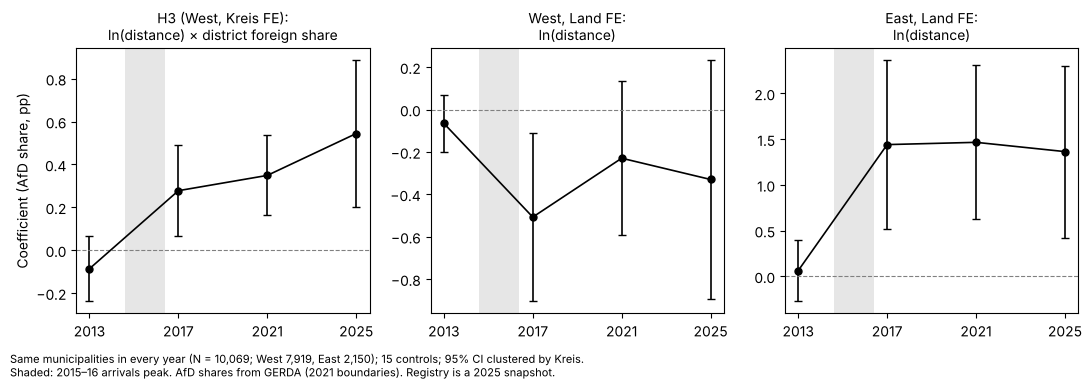

In [18]:
G = {"West": W.Kreis_code.nunique(), "East": E.Kreis_code.nunique()}
panels = [("West", "Kreis FE (H3)", "H3 (West, Kreis FE):\nln(distance) × district foreign share"),
          ("West", "Land FE", "West, Land FE:\nln(distance)"),
          ("East", "Land FE", "East, Land FE:\nln(distance)")]
fig, axs = plt.subplots(1, 3, figsize=(11, 3.6), sharex=True)
for ax, (s, mname, title) in zip(axs, panels):
    d = prof[(prof["sample"] == s) & (prof.model == mname)].sort_values("year")
    c = stats.t.ppf(.975, G[s] - 1)
    ax.errorbar(d.year, d.beta, yerr=c * d.SE_Kreis, fmt="o-", color="black", capsize=3, lw=1.2, ms=5)
    ax.axhline(0, color="0.5", ls="--", lw=.8)
    ax.axvspan(2014.6, 2016.4, color="0.9", lw=0)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([2013, 2017, 2021, 2025])
axs[0].set_ylabel("Coefficient (AfD share, pp)")
fig.text(0.01, -0.06, f"Same municipalities in every year (N = {len(B):,}; West {len(W):,}, East {len(E):,}); "
         "15 controls; 95% CI clustered by Kreis.\nShaded: 2015–16 arrivals peak. AfD shares from GERDA "
         "(2021 boundaries). Registry is a 2025 snapshot.", fontsize=8)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG / f"figure5_coefficients_by_election.{ext}", dpi=300, bbox_inches="tight")

**Results**

In [19]:
# Changes from 2013 (main H1 table)
t = pd.read_csv(OUT / '12_change_from_2013.csv')
display(t[['change', 'spec', 'N', 'beta', 'SE_Kreis', 'p_Kreis', 'WCB_p_Kreis', 'WCB_p_shelter']].round(4).reset_index(drop=True))

,change,spec,N,beta,SE_Kreis,p_Kreis,WCB_p_Kreis,WCB_p_shelter
0,2013->2017,West Kreis FE: H3 interaction,7919,0.3640,0.1017,0.0004,0.0002,0.0005
1,2013->2017,West Land FE: ln_distance,7919,-0.4420,0.1863,0.0183,0.0266,0.0120
2,2013->2017,West Kreis FE: ln_distance,7919,-0.2111,0.1043,0.0440,0.0460,0.0429
3,2013->2017,East Land FE: ln_distance,2150,1.3781,0.3748,0.0005,0.0029,0.0004
4,2013->2017,East excl. MV Land FE: ln_distance,1500,1.0506,0.4182,0.0147,0.0254,0.0015
5,2013->2017,East Kreis FE: ln_distance,2150,0.4448,0.3453,0.2022,0.1968,0.1633
6,2013->2021,West Kreis FE: H3 interaction,7919,0.4352,0.1022,0.0000,0.0001,0.0011
7,2013->2021,West Land FE: ln_distance,7919,-0.1643,0.1802,0.3625,0.4092,0.3877
8,2013->2021,West Kreis FE: ln_distance,7919,-0.0849,0.1270,0.5044,0.5056,0.6143
9,2013->2021,East Land FE: ln_distance,2150,1.4029,0.3584,0.0002,0.0053,0.0037


In [20]:
t = pd.read_csv(OUT / "11_coefficient_profile_by_election.csv")
display(t.pivot_table(index=["sample", "model", "term"], columns="year", values="beta", sort=False).round(3))
display(t.pivot_table(index=["sample", "model", "term"], columns="year", values="WCB_p_Kreis", sort=False).round(3))

year                                       2013   2017   2021   2025
sample  model             term                                      
Germany Land FE           ln_distance    -0.040  0.011  0.280  0.189
        Kreis FE          ln_distance    -0.156 -0.169  0.013  0.034
West    Land FE           ln_distance    -0.065 -0.507 -0.230 -0.330
        Kreis FE          ln_distance    -0.059 -0.270 -0.143 -0.114
        Kreis FE (H3)     ln_distance:Z  -0.086  0.278  0.349  0.544
        Land FE (density) n_centres_50km  0.101  0.281  0.174  0.263
East    Land FE           ln_distance     0.062  1.440  1.465  1.364
        Kreis FE          ln_distance    -0.381  0.063  0.090  0.007

year                                       2013   2017   2021   2025
sample  model             term                                      
Germany Land FE           ln_distance     0.572  0.967  0.262  0.532
        Kreis FE          ln_distance     0.019  0.171  0.923  0.845
West    Land FE           ln_distance     0.354  0.021  0.260  0.286
        Kreis FE          ln_distance     0.395  0.014  0.254  0.570
        Kreis FE (H3)     ln_distance:Z   0.288  0.013  0.001  0.002
        Land FE (density) n_centres_50km  0.000  0.000  0.000  0.000
East    Land FE           ln_distance     0.747  0.013  0.011  0.026
        Kreis FE          ln_distance     0.022  0.869  0.813  0.987

In [21]:
# Changes 2021-25 / 2017-25 and 2013 placebo levels
t = pd.read_csv(OUT / '10_gerda_change_and_placebo.csv')
display(t[['outcome', 'spec', 'sample', 'model', 'N', 'beta', 'SE_Kreis', 'p_Kreis', 'WCB_p_Kreis', 'WCB_p_shelter']].round(4).reset_index(drop=True))

,outcome,spec,sample,model,N,beta,SE_Kreis,p_Kreis,WCB_p_Kreis,WCB_p_shelter
0,Change AfD 2021-25,ln_distance,Germany,Land FE,10069,-0.0909,0.0953,0.3409,0.3721,0.3464
1,Change AfD 2021-25,ln_distance,Germany,Kreis FE,10069,0.0217,0.0870,0.8031,0.8098,0.8332
2,Change AfD 2021-25,ln_distance,West,Land FE,7919,-0.1003,0.1157,0.3866,0.4078,0.4050
3,Change AfD 2021-25,ln_distance,West,Kreis FE,7919,0.0291,0.1043,0.7806,0.7814,0.8321
4,Change AfD 2021-25,ln_distance,East,Land FE,2150,-0.1015,0.1402,0.4717,0.5581,0.5370
5,Change AfD 2021-25,ln_distance,East,Kreis FE,2150,-0.0831,0.1515,0.5851,0.5978,0.5324
6,Change AfD 2021-25,ln_distance,East excl. MV,Land FE,1500,-0.0595,0.1255,0.6370,0.6544,0.6874
7,Change AfD 2021-25,ln_distance,East excl. MV,Kreis FE,1500,-0.0030,0.1801,0.9869,0.9856,0.9823
8,Change AfD 2021-25,H3: ln_distance x district foreign share,West,Kreis FE,7919,0.1952,0.1030,0.0589,0.0696,0.0888
9,Change AfD 2021-25,n_centres_50km,West,Land FE,7919,0.0896,0.0286,0.0019,0.0047,0.0166


## 4. Zensus 2022 education and unemployment

```text
Key results with Zensus 2022 education and unemployment added to the 15 controls.

Zensus 2022 education results are sample-based and suppressed for small municipalities, so each
municipality gets its own value where published, else its Gemeindeverband's, else its Kreis's
(abitur/novoc/unemp: 14.6% / 42.9% / 42.4% of municipalities; 67% / 12% / 21% of population).
Fill-level dummies are included. Tertiary-degree shares are suppressed almost everywhere
(86% Kreis-only) and are not used.
  13_education_controls.csv     main comparison: 15 controls vs + education/unemployment
  13b_education_robustness.csv  one variable at a time; sample with sub-Kreis measures only
Caveat: measured in 2022, i.e. after the 2013->2017 change.
```

In [22]:
B = load_panel(require_years=True, require_edu=True)
W, E, EN = split(B)
W = with_z(W, "foreign_share_2021")
H3 = " + ln_distance:Z"
SPECS = [
    ("2025 level", "Germany", B, "ln_distance", LAND_FE, "afd2025", ""),
    ("2025 level", "Germany", B, "ln_distance", KREIS_FE, "afd2025", ""),
    ("2025 level", "West", W, "ln_distance", LAND_FE, "afd2025", ""),
    ("2025 level", "West", W, "ln_distance", KREIS_FE, "afd2025", ""),
    ("2025 level", "East", E, "ln_distance", LAND_FE, "afd2025", ""),
    ("2025 level", "East", E, "ln_distance", KREIS_FE, "afd2025", ""),
    ("H3 2025 level", "West", W, "ln_distance:Z", KREIS_FE, "afd2025", H3),
    ("H3 change 2013-17", "West", W, "ln_distance:Z", KREIS_FE, "I(afd2017-afd2013)", H3),
    ("H3 change 2013-25", "West", W, "ln_distance:Z", KREIS_FE, "I(afd2025-afd2013)", H3),
    ("H1 change 2013-17", "West", W, "ln_distance", LAND_FE, "I(afd2017-afd2013)", ""),
    ("H1 change 2013-17", "West", W, "ln_distance", KREIS_FE, "I(afd2017-afd2013)", ""),
    ("East change 2013-17", "East", E, "ln_distance", LAND_FE, "I(afd2017-afd2013)", ""),
    ("East change 2013-17", "East excl. MV", EN, "ln_distance", LAND_FE, "I(afd2017-afd2013)", ""),
    ("East change 2013-17", "East", E, "ln_distance", KREIS_FE, "I(afd2017-afd2013)", ""),
]
rows = []
for lab, sn, d, term, fe, y, extra in SPECS:
    for clab, ctrl in [("15 controls", CTRL), ("+ education/unemployment (Zensus 2022)", CTRL + " + " + EDU)]:
        m = fit(f"{y} ~ ln_distance{extra} + {fe} + {ctrl}", d)
        r = result_row(m, d, term, result=lab, sample=sn, FE="Land FE" if fe == LAND_FE else "Kreis FE", controls=clab)
        r.update(b_abitur=m.params.get("abitur_share_z22"), b_novoc=m.params.get("novoc_share_z22"),
                 b_unemp=m.params.get("unemp_rate_z22"))
        rows.append(r)
save(rows, "13_education_controls.csv")

KEY = [("West 2025 level H1", "Land FE", W, "ln_distance", LAND_FE, "afd2025", ""),
       ("West H1 change 2013-17", "Land FE", W, "ln_distance", LAND_FE, "I(afd2017-afd2013)", ""),
       ("West H1 change 2013-17", "Kreis FE", W, "ln_distance", KREIS_FE, "I(afd2017-afd2013)", ""),
       ("West H3 change 2013-25", "Kreis FE", W, "ln_distance:Z", KREIS_FE, "I(afd2025-afd2013)", H3),
       ("East change 2013-17", "Land FE", E, "ln_distance", LAND_FE, "I(afd2017-afd2013)", "")]
VAR = {"Abitur only": "abitur_share_z22 + edu_lvl_gv + edu_lvl_kr",
       "No-vocational only": "novoc_share_z22 + edu_lvl_gv + edu_lvl_kr",
       "Unemployment only": "unemp_rate_z22 + edu_lvl_gv + edu_lvl_kr",
       "All three, no level dummies": "abitur_share_z22 + novoc_share_z22 + unemp_rate_z22",
       "All three (main)": EDU}
rows = []
for lab, fen, d, term, fe, y, extra in KEY:
    for vl, v in VAR.items():
        samples = [("all", d)] + ([("sub-Kreis measure only", d[d.abitur_share_lvl != "Kreis"])]
                                  if vl == "All three (main)" else [])
        for samp, dd in samples:
            dd = with_z(dd, "foreign_share_2021") if extra else dd
            v2 = v if samp == "all" else v.replace(" + edu_lvl_kr", "")
            m = fit(f"{y} ~ ln_distance{extra} + {fe} + {CTRL} + {v2}", dd)
            rows.append(result_row(m, dd, term, result=lab, FE=fen, variant=vl, sample=samp))
save(rows, "13b_education_robustness.csv")

wrote outputs_extensions/13_education_controls.csv (28 rows)


wrote outputs_extensions/13b_education_robustness.csv (30 rows)


,result,FE,variant,sample,N,beta,SE_Kreis,p_Kreis,G_Kreis,WCB_p_Kreis,SE_shelter,p_shelter,G_shelter,WCB_p_shelter
0,West 2025 level H1,Land FE,Abitur only,all,7919,-0.639014,0.244535,0.009435,293,0.0214,0.213082,0.003316,117,0.0147
1,West 2025 level H1,Land FE,No-vocational only,all,7919,-0.410236,0.285931,0.152433,293,0.1904,0.259865,0.117139,117,0.1874
2,West 2025 level H1,Land FE,Unemployment only,all,7919,-0.320273,0.279665,0.253062,293,0.2911,0.244371,0.192581,117,0.2538
3,West 2025 level H1,Land FE,"All three, no level dummies",all,7919,-0.590218,0.237550,0.013530,293,0.0284,0.204780,0.004707,117,0.0176
4,West 2025 level H1,Land FE,All three (main),all,7919,-0.604112,0.238537,0.011847,293,0.0264,0.205749,0.004008,117,0.0163
5,West 2025 level H1,Land FE,All three (main),sub-Kreis measure only,5113,-0.470046,0.302008,0.120710,289,0.1739,0.247607,0.060178,115,0.1426
6,West H1 change 2013-17,Land FE,Abitur only,all,7919,-0.590708,0.171142,0.000640,293,0.0011,0.137649,0.000037,117,0.0004
7,West H1 change 2013-17,Land FE,No-vocational only,all,7919,-0.473979,0.187771,0.012125,293,0.0189,0.148360,0.001802,117,0.0079
8,West H1 change 2013-17,Land FE,Unemployment only,all,7919,-0.440766,0.183052,0.016666,293,0.0258,0.140490,0.002161,117,0.0098
9,West H1 change 2013-17,Land FE,"All three, no level dummies",all,7919,-0.567359,0.165525,0.000696,293,0.0015,0.134630,0.000050,117,0.0005


**Results**

In [23]:
t = pd.read_csv(OUT / "13_education_controls.csv")
display(t.pivot_table(index=["result", "sample", "FE"], columns="controls",
                      values=["beta", "WCB_p_Kreis", "WCB_p_shelter"], sort=False).round(3))

beta  \
controls                                   15 controls   
result              sample        FE                     
2025 level          Germany       Land FE        0.189   
                                  Kreis FE       0.034   
                    West          Land FE       -0.330   
                                  Kreis FE      -0.114   
                    East          Land FE        1.364   
                                  Kreis FE       0.007   
H3 2025 level       West          Kreis FE       0.544   
H3 change 2013-17   West          Kreis FE       0.364   
H3 change 2013-25   West          Kreis FE       0.630   
H1 change 2013-17   West          Land FE       -0.442   
                                  Kreis FE      -0.211   
East change 2013-17 East          Land FE        1.378   
                                  Kreis FE       0.445   
                    East excl. MV Land FE        1.051   

                                                                                   \
controls                                   + education/unemployment (Zensus 2022)   
result              sample        FE                                                
2025 level          Germany       Land FE                                  -0.093   
                                  Kreis FE                                 -0.063   
                    West          Land FE                                  -0.604   
                                  Kreis FE                                 -0.206   
                    East          Land FE                                   0.751   
                                  Kreis FE                                 -0.073   
H3 2025 level       West          Kreis FE                                  0.420   
H3 change 2013-17   West          Kreis FE                                  0.330   
H3 change 2013-25   West          Kreis FE                                  0.517   
H1 change 2013-17   West          Land FE                                  -0.575   
                                  Kreis FE                                 -0.259   
East change 2013-17 East          Land FE                                   1.002   
                                  Kreis FE                                  0.443   
                    East excl. MV Land FE                                   0.686   

                                           WCB_p_Kreis  \
controls                                   15 controls   
result              sample        FE                     
2025 level          Germany       Land FE        0.532   
                                  Kreis FE       0.845   
                    West          Land FE        0.286   
                                  Kreis FE       0.570   
                    East          Land FE        0.026   
                                  Kreis FE       0.987   
H3 2025 level       West          Kreis FE       0.002   
H3 change 2013-17   West          Kreis FE       0.000   
H3 change 2013-25   West          Kreis FE       0.000   
H1 change 2013-17   West          Land FE        0.027   
                                  Kreis FE       0.046   
East change 2013-17 East          Land FE        0.003   
                                  Kreis FE       0.197   
                    East excl. MV Land FE        0.025   

                                                                                   \
controls                                   + education/unemployment (Zensus 2022)   
result              sample        FE                                                
2025 level          Germany       Land FE                                   0.729   
                                  Kreis FE                                  0.712   
                    West          Land FE                                   0.026   
                                  Kreis FE                                  0.251   
                    East          L

In [24]:
t = pd.read_csv(OUT / '13b_education_robustness.csv')
display(t[['result', 'FE', 'variant', 'sample', 'N', 'beta', 'SE_Kreis', 'p_Kreis', 'WCB_p_Kreis', 'WCB_p_shelter']].round(4).reset_index(drop=True))

,result,FE,variant,sample,N,beta,SE_Kreis,p_Kreis,WCB_p_Kreis,WCB_p_shelter
0,West 2025 level H1,Land FE,Abitur only,all,7919,-0.6390,0.2445,0.0094,0.0214,0.0147
1,West 2025 level H1,Land FE,No-vocational only,all,7919,-0.4102,0.2859,0.1524,0.1904,0.1874
2,West 2025 level H1,Land FE,Unemployment only,all,7919,-0.3203,0.2797,0.2531,0.2911,0.2538
3,West 2025 level H1,Land FE,"All three, no level dummies",all,7919,-0.5902,0.2376,0.0135,0.0284,0.0176
4,West 2025 level H1,Land FE,All three (main),all,7919,-0.6041,0.2385,0.0118,0.0264,0.0163
5,West 2025 level H1,Land FE,All three (main),sub-Kreis measure only,5113,-0.4700,0.3020,0.1207,0.1739,0.1426
6,West H1 change 2013-17,Land FE,Abitur only,all,7919,-0.5907,0.1711,0.0006,0.0011,0.0004
7,West H1 change 2013-17,Land FE,No-vocational only,all,7919,-0.4740,0.1878,0.0121,0.0189,0.0079
8,West H1 change 2013-17,Land FE,Unemployment only,all,7919,-0.4408,0.1831,0.0167,0.0258,0.0098
9,West H1 change 2013-17,Land FE,"All three, no level dummies",all,7919,-0.5674,0.1655,0.0007,0.0015,0.0005


## 5. H3 with pre-crisis diversity (Zensus 2011)

```text
H3 with pre-crisis diversity: foreign share from Zensus 2011 (09.05.2011), mapped to 2021
boundaries. Answers the objection that INKAR 2021 / Zensus 2022 diversity is measured after the
2015-16 arrivals. Moderators (z-scored within sample):
  kreis_foreign_share_z2011   district share, computed from all municipalities of the Kreis
  foreign_share_z2011         municipal share (varies within Kreis)
  foreign_share_2021          district share, INKAR 2021 (main specification, for comparison)
Kreis FE, constant 2013-2025 sample, with and without Zensus 2022 education controls.
Outputs: 14_h3_zensus2011_moderator.csv
         14b_zensus2011_dash_sensitivity.csv  ("-" = 0 / 1 / 2, or municipalities with "-" dropped;
                                               West, Kreis FE, with education controls)
```

In [25]:
import pandas as pd

z = pd.read_csv(DERIVED / "zensus2011_foreign.csv", dtype={"AGS8": str})
kd = z.assign(Kreis_code=z.AGS8.str[:5]).groupby("Kreis_code")[["foreign2011_z11", "pop2011_z11"]].sum()
kshare = 100 * kd.foreign2011_z11 / kd.pop2011_z11
B = load_panel(require_years=True, require_edu=True)
B = B.reset_index().merge(z, on="AGS8", how="left").set_index("index").dropna(subset=["foreign_share_z2011"])
B["kreis_foreign_share_z2011"] = B.Kreis_code.str.zfill(5).map(kshare)
W, E, _ = split(B)
MODS = {"kreis_foreign_share_z2011": "District foreign share, Zensus 2011",
        "foreign_share_z2011": "Municipal foreign share, Zensus 2011",
        "foreign_share_2021": "District foreign share, INKAR 2021 (main)"}
OUTS = {"afd2013": "Level 2013 (placebo)", "afd2017": "Level 2017", "afd2025": "Level 2025",
        "I(afd2017-afd2013)": "Change 2013-17", "I(afd2025-afd2013)": "Change 2013-25"}
rows = []
for sn, S in [("West", W), ("East", E)]:
    for mod, mlab in MODS.items():
        d = with_z(S, mod)
        # the municipal 2011 share varies within Kreis, so its main effect stays in the model
        core = "ln_distance * Z" if mod == "foreign_share_z2011" else "ln_distance + ln_distance:Z"
        for y, ylab in OUTS.items():
            for clab, ctrl in [("15 controls", CTRL), ("+ education", CTRL + " + " + EDU)]:
                m = fit(f"{y} ~ {core} + {KREIS_FE} + {ctrl}", d)
                rows.append(result_row(m, d, "ln_distance:Z", sample=sn, moderator=mlab, outcome=ylab, controls=clab))
save(rows, "14_h3_zensus2011_moderator.csv")

wrote outputs_extensions/14_h3_zensus2011_moderator.csv (60 rows)


,sample,moderator,outcome,controls,N,beta,SE_Kreis,p_Kreis,G_Kreis,WCB_p_Kreis,SE_shelter,p_shelter,G_shelter,WCB_p_shelter
0,West,"District foreign share, Zensus 2011",Level 2013 (placebo),15 controls,7919,-0.037680,0.061246,0.538888,293,0.5367,0.061426,0.540802,117,0.5608
1,West,"District foreign share, Zensus 2011",Level 2013 (placebo),+ education,7919,-0.047772,0.062945,0.448498,293,0.4584,0.061351,0.437769,117,0.4628
2,West,"District foreign share, Zensus 2011",Level 2017,15 controls,7919,0.332720,0.092190,0.000361,293,0.0005,0.082075,0.000092,117,0.0004
3,West,"District foreign share, Zensus 2011",Level 2017,+ education,7919,0.279352,0.095140,0.003587,293,0.0039,0.083056,0.001044,117,0.0018
4,West,"District foreign share, Zensus 2011",Level 2025,15 controls,7919,0.591197,0.169009,0.000542,293,0.0006,0.158551,0.000299,117,0.0008
5,West,"District foreign share, Zensus 2011",Level 2025,+ education,7919,0.442659,0.161806,0.006605,293,0.0090,0.146587,0.003112,117,0.0044
6,West,"District foreign share, Zensus 2011",Change 2013-17,15 controls,7919,0.370400,0.096585,0.000154,293,0.0001,0.088086,0.000052,117,0.0001
7,West,"District foreign share, Zensus 2011",Change 2013-17,+ education,7919,0.327124,0.101002,0.001339,293,0.0009,0.094815,0.000782,117,0.0005
8,West,"District foreign share, Zensus 2011",Change 2013-25,15 controls,7919,0.628877,0.173470,0.000340,293,0.0003,0.169512,0.000320,117,0.0006
9,West,"District foreign share, Zensus 2011",Change 2013-25,+ education,7919,0.490431,0.167385,0.003658,293,0.0047,0.164495,0.003497,117,0.0064


### Sensitivity to cells published as "-" (SAFE turns counts of 1-2 into 0 or 3)

In [26]:
def shares(dash_value, drop=False):
    o = z.set_index("AGS8")
    f = o.foreign2011_z11 + dash_value * o.dash_w_z11
    muni = (100 * f / o.pop2011_z11).where(~(drop & (o.dash_w_z11 > 0)))
    k = pd.DataFrame({"f": f, "p": o.pop2011_z11}).groupby(o.index.str[:5]).sum()
    return pd.DataFrame({"muni": muni, "kreis": o.index.str[:5].map(100 * k.f / k.p)}, index=o.index)

VARIANTS = {"'-' = 0 (official: nichts vorhanden)": (0, False), "'-' = 1": (1, False),
            "'-' = 2 (upper bound under SAFE)": (2, False), "drop municipalities with '-'": (0, True)}
SENS_OUT = {"afd2013": "2013 placebo", "I(afd2017-afd2013)": "Change 2013-17", "I(afd2025-afd2013)": "Change 2013-25"}
rows = []
for vl, (v, dr) in VARIANTS.items():
    d0 = W.drop(columns=["foreign_share_z2011", "kreis_foreign_share_z2011"]).join(shares(v, dr), on="AGS8")
    for mod, core, mlab in [("kreis", "ln_distance + ln_distance:Z", "District 2011"),
                            ("muni", "ln_distance * Z", "Municipal 2011")]:
        d = with_z(d0.dropna(subset=[mod]), mod)
        for y, ylab in SENS_OUT.items():
            m = fit(f"{y} ~ {core} + {KREIS_FE} + {CTRL} + {EDU}", d)
            rows.append(result_row(m, d, "ln_distance:Z", variant=vl, moderator=mlab, outcome=ylab))
save(rows, "14b_zensus2011_dash_sensitivity.csv")

wrote outputs_extensions/14b_zensus2011_dash_sensitivity.csv (24 rows)


,variant,moderator,outcome,N,beta,SE_Kreis,p_Kreis,G_Kreis,WCB_p_Kreis,SE_shelter,p_shelter,G_shelter,WCB_p_shelter
0,'-' = 0 (official: nichts vorhanden),District 2011,2013 placebo,7919,-0.047772,0.062945,0.448498,293,0.4584,0.061351,0.437769,117,0.4628
1,'-' = 0 (official: nichts vorhanden),District 2011,Change 2013-17,7919,0.327124,0.101002,0.001339,293,0.0009,0.094815,0.000782,117,0.0005
2,'-' = 0 (official: nichts vorhanden),District 2011,Change 2013-25,7919,0.490431,0.167385,0.003658,293,0.0047,0.164495,0.003497,117,0.0064
3,'-' = 0 (official: nichts vorhanden),Municipal 2011,2013 placebo,7919,-0.036070,0.033096,0.276674,293,0.2794,0.041300,0.384257,117,0.4163
4,'-' = 0 (official: nichts vorhanden),Municipal 2011,Change 2013-17,7919,0.173480,0.050108,0.000616,293,0.0015,0.043480,0.000116,117,0.0010
5,'-' = 0 (official: nichts vorhanden),Municipal 2011,Change 2013-25,7919,0.217219,0.106891,0.043042,293,0.0499,0.102501,0.036207,117,0.0462
6,'-' = 1,District 2011,2013 placebo,7919,-0.048020,0.063091,0.447199,293,0.4568,0.061474,0.436315,117,0.4608
7,'-' = 1,District 2011,Change 2013-17,7919,0.327139,0.101047,0.001345,293,0.0009,0.094862,0.000786,117,0.0005
8,'-' = 1,District 2011,Change 2013-25,7919,0.490176,0.167482,0.003694,293,0.0047,0.164648,0.003543,117,0.0066
9,'-' = 1,Municipal 2011,2013 placebo,7919,-0.033439,0.032863,0.309757,293,0.3121,0.040991,0.416310,117,0.4461


**Results**

In [27]:
# West (the East shows no moderation; see the csv)
t = pd.read_csv(OUT / '14_h3_zensus2011_moderator.csv').query("sample == 'West'")
display(t[['sample', 'moderator', 'outcome', 'controls', 'N', 'beta', 'SE_Kreis', 'p_Kreis', 'WCB_p_Kreis', 'WCB_p_shelter']].round(4).reset_index(drop=True))

,sample,moderator,outcome,controls,N,beta,SE_Kreis,p_Kreis,WCB_p_Kreis,WCB_p_shelter
0,West,"District foreign share, Zensus 2011",Level 2013 (placebo),15 controls,7919,-0.0377,0.0612,0.5389,0.5367,0.5608
1,West,"District foreign share, Zensus 2011",Level 2013 (placebo),+ education,7919,-0.0478,0.0629,0.4485,0.4584,0.4628
2,West,"District foreign share, Zensus 2011",Level 2017,15 controls,7919,0.3327,0.0922,0.0004,0.0005,0.0004
3,West,"District foreign share, Zensus 2011",Level 2017,+ education,7919,0.2794,0.0951,0.0036,0.0039,0.0018
4,West,"District foreign share, Zensus 2011",Level 2025,15 controls,7919,0.5912,0.1690,0.0005,0.0006,0.0008
5,West,"District foreign share, Zensus 2011",Level 2025,+ education,7919,0.4427,0.1618,0.0066,0.0090,0.0044
6,West,"District foreign share, Zensus 2011",Change 2013-17,15 controls,7919,0.3704,0.0966,0.0002,0.0001,0.0001
7,West,"District foreign share, Zensus 2011",Change 2013-17,+ education,7919,0.3271,0.1010,0.0013,0.0009,0.0005
8,West,"District foreign share, Zensus 2011",Change 2013-25,15 controls,7919,0.6289,0.1735,0.0003,0.0003,0.0006
9,West,"District foreign share, Zensus 2011",Change 2013-25,+ education,7919,0.4904,0.1674,0.0037,0.0047,0.0064


In [28]:
t = pd.read_csv(OUT / '14b_zensus2011_dash_sensitivity.csv')
display(t[['moderator', 'variant', 'outcome', 'N', 'beta', 'SE_Kreis', 'p_Kreis', 'WCB_p_Kreis', 'WCB_p_shelter']].round(4).reset_index(drop=True))

,moderator,variant,outcome,N,beta,SE_Kreis,p_Kreis,WCB_p_Kreis,WCB_p_shelter
0,District 2011,'-' = 0 (official: nichts vorhanden),2013 placebo,7919,-0.0478,0.0629,0.4485,0.4584,0.4628
1,District 2011,'-' = 0 (official: nichts vorhanden),Change 2013-17,7919,0.3271,0.1010,0.0013,0.0009,0.0005
2,District 2011,'-' = 0 (official: nichts vorhanden),Change 2013-25,7919,0.4904,0.1674,0.0037,0.0047,0.0064
3,Municipal 2011,'-' = 0 (official: nichts vorhanden),2013 placebo,7919,-0.0361,0.0331,0.2767,0.2794,0.4163
4,Municipal 2011,'-' = 0 (official: nichts vorhanden),Change 2013-17,7919,0.1735,0.0501,0.0006,0.0015,0.0010
5,Municipal 2011,'-' = 0 (official: nichts vorhanden),Change 2013-25,7919,0.2172,0.1069,0.0430,0.0499,0.0462
6,District 2011,'-' = 1,2013 placebo,7919,-0.0480,0.0631,0.4472,0.4568,0.4608
7,District 2011,'-' = 1,Change 2013-17,7919,0.3271,0.1010,0.0013,0.0009,0.0005
8,District 2011,'-' = 1,Change 2013-25,7919,0.4902,0.1675,0.0037,0.0047,0.0066
9,Municipal 2011,'-' = 1,2013 placebo,7919,-0.0334,0.0329,0.3098,0.3121,0.4461


## 6. Map

```text
Figure 0: AfD vote share 2025 by district and the 157 reception centres.
Needs data/derived/{districts_vg250,laender_vg250}.geojson, kreis_afd_2025.csv and the raw
registry data/raw/refugee_centres_raw_data_2025.xlsx (not committed).
```
The raw registry is not committed; without it this cell prints a note and the committed figure is kept.

wrote figure0_map_afd2025_centres


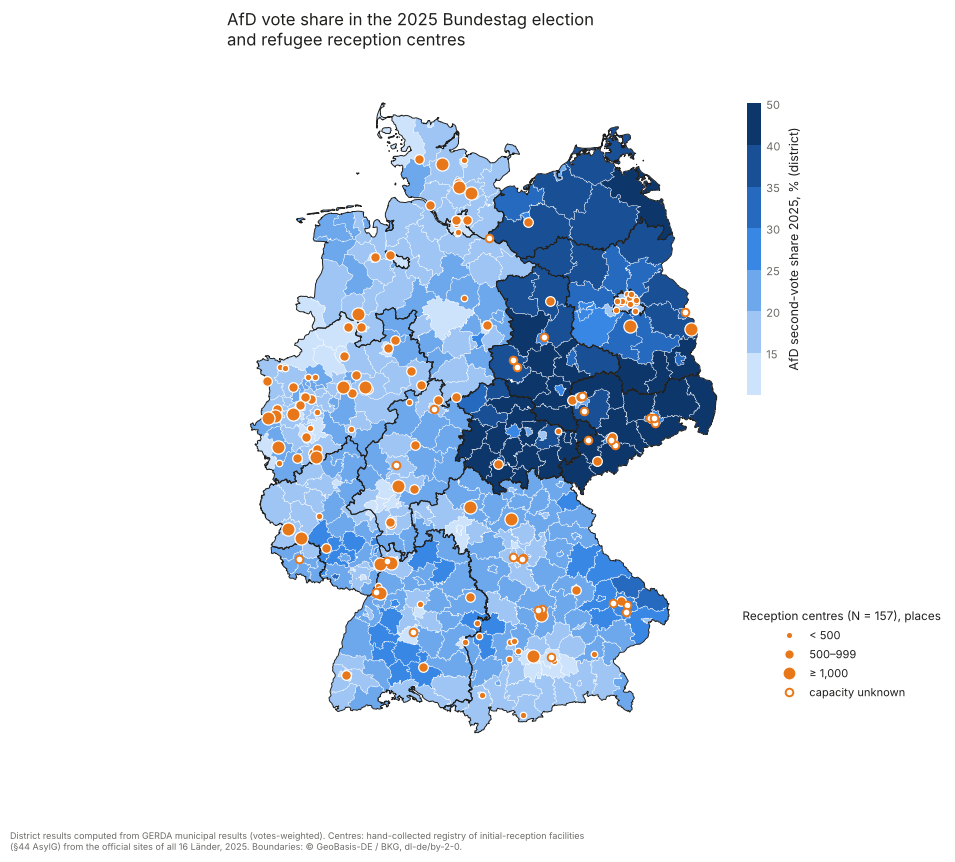

In [29]:
import numpy as np, pandas as pd, geopandas as gpd, matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D

REG = RAW / "refugee_centres_raw_data_2025.xlsx"
if REG.exists():
    krs = gpd.read_file(DERIVED / "districts_vg250.geojson").to_crs("EPSG:25832")
    lan = gpd.read_file(DERIVED / "laender_vg250.geojson").to_crs("EPSG:25832")
    k = pd.read_csv(DERIVED / "kreis_afd_2025.csv", dtype={"Kreis_code": str})
    krs = krs.merge(k, on="Kreis_code", how="left")
    assert krs.afd2025_pct.notna().all()
    reg = pd.read_excel(REG, "Database")
    c = gpd.GeoDataFrame(reg, geometry=gpd.points_from_xy(reg.Longitude, reg.Latitude), crs="EPSG:4326").to_crs("EPSG:25832")
    cls = pd.cut(c.Capacity, [0, 500, 1000, np.inf], right=False, labels=["< 500", "500–999", "≥ 1,000"])
    size = {"< 500": 22, "500–999": 48, "≥ 1,000": 90}

    ramp = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]   # one hue, light->dark
    bounds = [5, 15, 20, 25, 30, 35, 40, 50]
    cmap, norm = ListedColormap(ramp), BoundaryNorm(bounds, len(ramp))
    ACC, INK, MUTED = "#e8771a", "#1f1f1e", "#6b6b68"

    fig, ax = plt.subplots(figsize=(8.6, 9.0))
    krs.plot(ax=ax, column="afd2025_pct", cmap=cmap, norm=norm, edgecolor="white", linewidth=0.25)
    lan.boundary.plot(ax=ax, color=INK, linewidth=0.7)
    for lab in size:
        s = c[cls == lab]
        ax.scatter(s.geometry.x, s.geometry.y, s=size[lab], c=ACC, edgecolor="white", linewidth=0.9, zorder=3)
    s = c[c.Capacity.isna()]
    ax.scatter(s.geometry.x, s.geometry.y, s=30, facecolor="white", edgecolor=ACC, linewidth=1.4, zorder=3)
    ax.set_axis_off()
    cb = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax, fraction=0.03, pad=0.01, shrink=0.42,
                      anchor=(0, 0.92), ticks=bounds, spacing="uniform")
    cb.ax.set_yticklabels([""] + [str(b) for b in bounds[1:]])
    cb.set_label("AfD second-vote share 2025, % (district)", color=INK, fontsize=9)
    cb.ax.tick_params(labelsize=8, colors=MUTED, length=0)
    cb.outline.set_visible(False)
    h = [Line2D([], [], ls="", marker="o", ms=np.sqrt(size[l]), mfc=ACC, mec="white", label=l) for l in size]
    h.append(Line2D([], [], ls="", marker="o", ms=np.sqrt(30), mfc="white", mec=ACC, mew=1.4, label="capacity unknown"))
    leg = ax.legend(handles=h, title=f"Reception centres (N = {len(c)}), places", loc="lower left",
                    bbox_to_anchor=(0.985, 0.08), frameon=False, fontsize=8, title_fontsize=8.5, labelcolor=INK)
    leg.get_title().set_color(INK)
    ax.set_title("AfD vote share in the 2025 Bundestag election\nand refugee reception centres", fontsize=12, color=INK, loc="left")
    fig.text(0.02, 0.015, "District results computed from GERDA municipal results (votes-weighted). Centres: hand-collected registry of "
             "initial-reception facilities\n(§44 AsylG) from the official sites of all 16 Länder, 2025. Boundaries: © GeoBasis-DE / BKG, dl-de/by-2-0.",
             fontsize=6.5, color=MUTED)
    for ext in ("png", "pdf"):
        fig.savefig(FIG / f"figure0_map_afd2025_centres.{ext}", dpi=300, bbox_inches="tight", facecolor="white")
    print("wrote figure0_map_afd2025_centres")
else:
    print("registry not found in data/raw/ - map skipped; see outputs_extensions/figures/")